# Exploration des annonces de location — Sénégal

Ce notebook trace la phase d'**exploration et de nettoyage** des données brutes
issues du scraping (`data/raw/locations.csv`). Il ne contient **aucune logique
de production** : les décisions prises ici (bornes de filtrage, réconciliation
`meuble`, imputation) sont ensuite implémentées et testées dans
`src/senegal_rental_price/data/preprocessing.py`, réutilisé en toute fin de
notebook pour vérifier que le module de production reproduit bien l'analyse.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Chargement des données brutes

In [2]:
df = pd.read_csv("../data/raw/locations.csv", sep=";", encoding="utf-8-sig")
print(df.shape)
df.head(3)

(166, 14)


,id,ville,quartier,type_bien,surface_m2,surface_estimee,nb_pieces,nb_chambres,meuble,equipements,prix_loyer_mensuel,titre,adresse,date_publication
0,6a3a5671468a708472e39b6a,Dakar,Mermoz - Sacré-Cœur,appartement,67.2,True,3.0,2.0,False,piscine|gardiennage|parking|salle_de_sport,900000,Bel appartement neuf à Mermoz,NaN,2026-06-23T09:48:33.330Z
1,6a3a54fd468a708472e39b5d,Dakar,Fann - Point E,appartement,64.2,True,3.0,2.0,False,climatisation|gardiennage|parking|meuble,1150000,À LOUER - APPARTEMENT MEUBLÉ HAUT STANDING AU ...,NaN,2026-06-23T09:42:21.990Z
2,6a3a5453468a708472e39b56,Dakar,Almadies,appartement,73.4,True,3.0,2.0,False,piscine|climatisation|gardiennage|meuble,900000,À LOUER – APPARTEMENT HAUT STANDING AUX ALMADIES,NaN,2026-06-23T09:39:31.089Z


## 2. Aperçu général — types et valeurs manquantes

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  166 non-null    object 
 1   ville               166 non-null    object 
 2   quartier            166 non-null    object 
 3   type_bien           166 non-null    object 
 4   surface_m2          166 non-null    float64
 5   surface_estimee     166 non-null    bool   
 6   nb_pieces           160 non-null    float64
 7   nb_chambres         159 non-null    float64
 8   meuble              164 non-null    object 
 9   equipements         155 non-null    object 
 10  prix_loyer_mensuel  166 non-null    int64  
 11  titre               166 non-null    object 
 12  adresse             3 non-null      object 
 13  date_publication    166 non-null    object 
dtypes: bool(1), float64(3), int64(1), object(9)
memory usage: 17.2+ KB


In [4]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

adresse        163
equipements     11
nb_chambres      7
nb_pieces        6
meuble           2
dtype: int64

`adresse` est quasi toujours vide, `nb_pieces`/`nb_chambres`/`equipements` ont
quelques trous, `surface_estimee` et `meuble` contiennent aussi des `NaN`
(traités comme "non renseigné" -> `False` au nettoyage).

## 3. Répartition ville / type de bien

In [5]:
display(df["ville"].value_counts())
display(df["type_bien"].value_counts())

ville
Thiès         94
Dakar         71
Diakhirate     1
Name: count, dtype: int64

type_bien
maison         98
appartement    68
Name: count, dtype: int64

`Diakhirate` n'apparaît qu'une seule fois : insuffisant pour généraliser, ce
sera écarté (restriction aux villes connues : Dakar, Thiès — cette dernière
recouvrant en réalité la Petite-Côte : Saly, Ngaparou, Somone via le
`quartier`).

## 4. Distribution du prix brut — recherche de valeurs aberrantes

In [6]:
df["prix_loyer_mensuel"].describe()

count    1.660000e+02
mean     1.243672e+06
std      1.289828e+06
min      3.500000e+03
25%      6.500000e+05
50%      1.000000e+06
75%      1.500000e+06
max      1.500000e+07
Name: prix_loyer_mensuel, dtype: float64

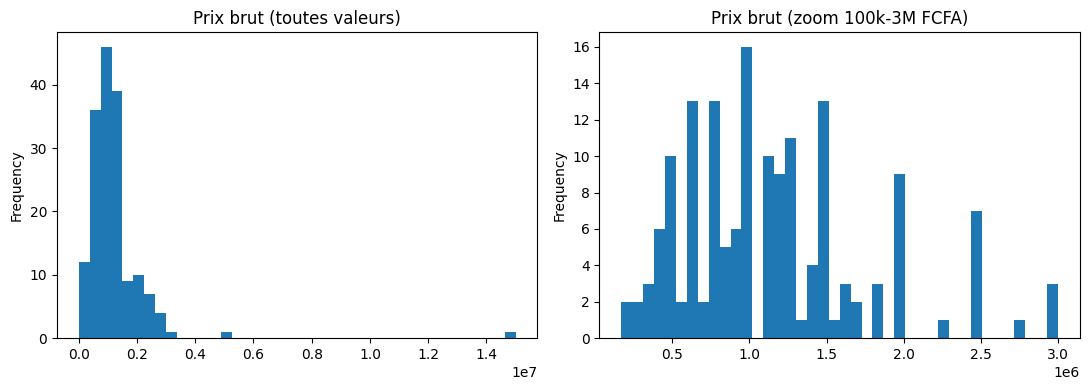

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["prix_loyer_mensuel"].plot(kind="hist", bins=40, ax=ax[0], title="Prix brut (toutes valeurs)")
df.loc[df["prix_loyer_mensuel"].between(100_000, 3_000_000), "prix_loyer_mensuel"].plot(
    kind="hist", bins=40, ax=ax[1], title="Prix brut (zoom 100k-3M FCFA)"
)
plt.tight_layout()

In [8]:
# Les loyers les plus bas ressemblent à des locaux commerciaux, pas des logements
df.nsmallest(8, "prix_loyer_mensuel")[["titre", "type_bien", "surface_m2", "prix_loyer_mensuel"]]

,titre,type_bien,surface_m2,prix_loyer_mensuel
119,DAKAR PLATEAU : Location entrepôts – Zone indu...,maison,85.1,3500
102,DAKAR MERMOZ : Plateau de bureaux à louer,maison,203.5,9000
85,DAKAR PLATEAU : Local commercial à louer – LA ...,maison,88.6,12000
9,DAKAR NGOR : Appartement 2 chambres salon meub...,appartement,62.9,50000
27,DAKAR CITÉ KEUR GORGUI : Appartement meublé à ...,appartement,79.4,65000
3,Appartement à louer,appartement,75.3,170000
73,NGAPAROU : T1 meublé dans résidence privée à l...,maison,56.7,210000
50,NGAPAROU : Appartement à louer,appartement,43.4,280000


In [9]:
df.nlargest(5, "prix_loyer_mensuel")[["titre", "type_bien", "surface_m2", "prix_loyer_mensuel"]]

,titre,type_bien,surface_m2,prix_loyer_mensuel
72,À LOUER AUX ALMADIES – IMMEUBLE R+1 EN BORD DE...,maison,99.9,15000000
95,DAKAR POINT-E : Plateau de bureaux à louer,maison,500.0,5000000
21,DAKAR MERMOZ : Appartement à louer 4 chambres ...,appartement,127.7,3250000
28,DAKAR MERMOZ : Appartement à louer 4 chambres ...,appartement,120.0,3000000
68,LOUER AUX ALMADIES - VILLA R+1 DE STANDING,maison,700.0,3000000


### Biens non résidentiels détectés via le titre

Les loyers les plus bas (3 500 à 12 000 FCFA) correspondent à des "locaux
commerciaux", "bureaux", "entrepôts" ou "plateaux de bureaux" — pas à des
logements résidentiels. On les détecte via des mots-clés du titre.

In [10]:
commercial_keywords = ["commercial", "bureau", "entrep", "local", "plateau de bureaux", "immeuble"]
title = df["titre"].fillna("").str.lower()
is_commercial = title.apply(lambda t: any(kw in t for kw in commercial_keywords))
print(f"{is_commercial.sum()} annonces non résidentielles détectées sur {len(df)}")
df.loc[is_commercial, ["titre", "type_bien", "prix_loyer_mensuel"]]

8 annonces non résidentielles détectées sur 166


,titre,type_bien,prix_loyer_mensuel
33,DAKAR ALMADIES : Appartement à louer – 3 chamb...,appartement,2750000
72,À LOUER AUX ALMADIES – IMMEUBLE R+1 EN BORD DE...,maison,15000000
85,DAKAR PLATEAU : Local commercial à louer – LA ...,maison,12000
95,DAKAR POINT-E : Plateau de bureaux à louer,maison,5000000
102,DAKAR MERMOZ : Plateau de bureaux à louer,maison,9000
119,DAKAR PLATEAU : Location entrepôts – Zone indu...,maison,3500
156,DAKAR CITÉ KEUR GORGUI : Location plateau de b...,maison,1000000
160,DAKAR POINT-E : Bureau meublé à louer,maison,1200000


## 5. Incohérence de la colonne `meuble`

In [11]:
col_meuble = df["meuble"].astype(str).str.lower().eq("true").sum()
equip_meuble = df["equipements"].fillna("").str.lower().str.contains("meuble").sum()
print(f"Colonne 'meuble' = True : {col_meuble} annonces")
print(f"Token 'meuble' présent dans 'equipements' : {equip_meuble} annonces")

Colonne 'meuble' = True : 3 annonces
Token 'meuble' présent dans 'equipements' : 60 annonces


La colonne `meuble` est très peu renseignée (3 biens) alors que le token
`meuble` apparaît 60 fois dans `equipements`. **Décision** : un bien est
considéré meublé si la colonne *ou* les équipements l'indiquent
(`preprocessing.reconcile_meuble`).

## 6. Équipements — fréquence

equipements
piscine           95
gardiennage       89
terrasse          73
meuble            60
parking           54
jardin            54
climatisation     27
salle_de_sport    16
wifi               8
Name: count, dtype: int64

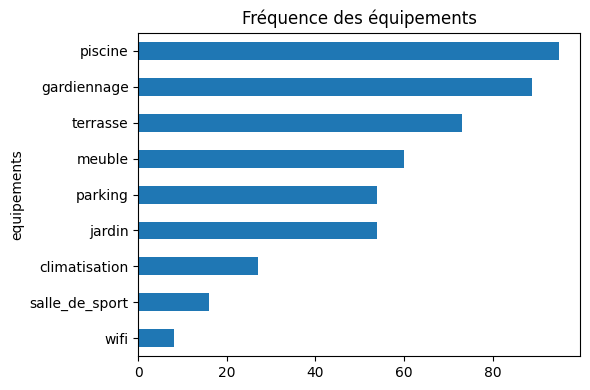

In [12]:
equip_counts = (
    df["equipements"].fillna("").str.split("|").explode().str.strip().str.lower()
)
equip_counts = equip_counts[equip_counts != ""].value_counts()
equip_counts.plot(kind="barh", figsize=(6, 4), title="Fréquence des équipements")
plt.gca().invert_yaxis()
plt.tight_layout()
equip_counts

## 7. Distribution de la surface

In [13]:
df["surface_m2"].describe()

count    166.000000
mean     257.413253
std      238.074720
min       43.000000
25%       89.625000
50%      164.250000
75%      298.525000
max      900.000000
Name: surface_m2, dtype: float64

In [14]:
# surface_estimee=False correspond souvent à une surface de parcelle/terrain
# (villas 600-900 m2), pas à la surface habitable -> reste plausible mais
# gonfle la variance ; on le garde comme feature (`surface_estimee`) plutôt
# que de l'écarter.
df.groupby("surface_estimee")["surface_m2"].describe()[["count", "mean", "50%", "max"]]

,count,mean,50%,max
surface_estimee,,,,
False,49.0,553.061224,600.0,900.0
True,117.0,133.594872,107.5,314.1


## 8. Décisions de nettoyage retenues

| Problème | Décision | Implémentation |
|---|---|---|
| Biens non résidentiels | Filtrage par mots-clés du titre | `filter_listings` |
| Prix / surface aberrants | Bornes de plausibilité (`conf/data/default.yaml`) | `filter_listings` |
| `Diakhirate` (1 annonce), villes/types rares | Restriction aux valeurs connues | `filter_listings` |
| `meuble` peu fiable | Réconciliation avec `equipements` | `reconcile_meuble` |
| `nb_pieces` / `nb_chambres` manquants | Imputation par la médiane par `type_bien` | `impute_missing` |
| `id`, `adresse`, `date_publication` | Colonnes non prédictives, supprimées | `clean` |

On vérifie maintenant que le module de production (`preprocessing.py`)
reproduit bien cette analyse, avec les mêmes bornes que celles utilisées ici.

In [15]:
import sys

sys.path.insert(0, "../src")

from senegal_rental_price.data.preprocessing import CleaningConfig, clean, load_raw

raw = load_raw("../data/raw/locations.csv")
cfg = CleaningConfig(
    known_villes=("Dakar", "Thiès"),
    known_types=("appartement", "maison"),
)
clean_df = clean(raw, cfg)
print(f"{len(raw)} annonces brutes -> {len(clean_df)} annonces propres")
clean_df.head(3)

2026-07-23 13:39:49 | INFO     | senegal_rental_price.data.preprocessing | Données brutes chargées : 166 lignes, 14 colonnes


2026-07-23 13:39:49 | INFO     | senegal_rental_price.data.preprocessing | Filtrage : 166 -> 155 lignes (11 écartées : commercial/aberrant)


2026-07-23 13:39:49 | INFO     | senegal_rental_price.data.preprocessing | Nettoyage terminé : 155 lignes propres


166 annonces brutes -> 155 annonces propres


,ville,quartier,type_bien,surface_m2,surface_estimee,nb_pieces,nb_chambres,meuble,equipements,prix_loyer_mensuel,titre
0,Dakar,Mermoz - Sacré-Cœur,appartement,67.2,True,3,2,False,"[piscine, gardiennage, parking, salle_de_sport]",900000,Bel appartement neuf à Mermoz
1,Dakar,Fann - Point E,appartement,64.2,True,3,2,True,"[climatisation, gardiennage, parking, meuble]",1150000,À LOUER - APPARTEMENT MEUBLÉ HAUT STANDING AU ...
2,Dakar,Almadies,appartement,73.4,True,3,2,True,"[piscine, climatisation, gardiennage, meuble]",900000,À LOUER – APPARTEMENT HAUT STANDING AUX ALMADIES


## 9. Prix nettoyé — distribution finale par ville

,count,mean,50%,min,max
ville,,,,,
Dakar,61.0,1.326230e+06,1150000.0,300000.0,3250000.0
Thiès,94.0,1.066915e+06,1000000.0,210000.0,2500000.0


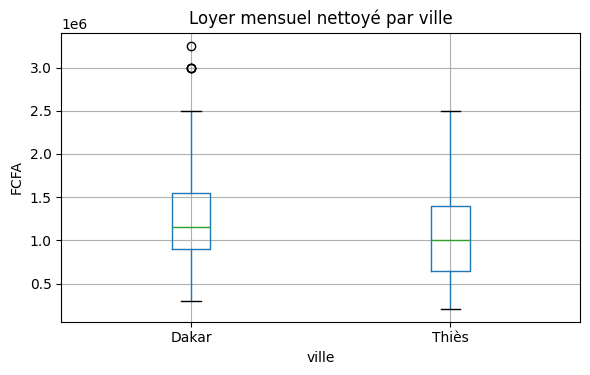

In [16]:
clean_df.boxplot(column="prix_loyer_mensuel", by="ville", figsize=(6, 4))
plt.title("Loyer mensuel nettoyé par ville")
plt.suptitle("")
plt.ylabel("FCFA")
plt.tight_layout()
clean_df.groupby("ville")["prix_loyer_mensuel"].describe()[["count", "mean", "50%", "min", "max"]]

## 10. Conclusion

Après nettoyage, le jeu de données passe de 166 à ~155 annonces exploitables,
avec des prix désormais plausibles (pas de local commercial à 3 500 FCFA/mois
ni d'immeuble entier à 15M FCFA). Cette analyse est documentée de façon
synthétique dans `data/README.md` et entièrement opérationnalisée, testée et
typée dans `src/senegal_rental_price/data/preprocessing.py`
(cf. `tests/test_preprocessing.py`).

La suite du pipeline (construction des features, entraînement, comparaison de
modèles) est décrite dans le README principal du projet.